# Project Report: Time Series Analysis and Modeling using Statistical Models
---

**Master's Degree in Machine Learning** **Subject:** Time Series  
**Date:** 26/02/2026

---

## Project Identification
* **Authors:** 
    * Andrés Malón
    * Roberto Aldanondo
* **Program:** Master's Degree in Machine Learning
* **Repository:** [Link to Project Repository](https://github.com/a139573/TimeSeriesAssessments)

---

## Description
The goal of this group project is to analyze an assigned time series dataset, identify its underlying patterns, and apply the most appropriate statistical model to forecast future values. 

## 1. Descriptive Analysis (Exploratory Data Analysis)

### 1.1 Conduct a thorough visual and statistical exploration of the assigned time series

Load the data

In [71]:
import pandas as pd

df = pd.read_csv("Data/chatfield_monthly_sales.csv")
print(df.head())

         date  sales
0  1965-01-01    154
1  1965-02-01     96
2  1965-03-01     73
3  1965-04-01     49
4  1965-05-01     36


Check when the series starts and ends

In [72]:
print(df['date'])

0     1965-01-01
1     1965-02-01
2     1965-03-01
3     1965-04-01
4     1965-05-01
         ...    
68    1971-01-01
69    1971-02-01
70    1971-03-01
71    1971-04-01
72    1971-05-01
Name: date, Length: 73, dtype: object


Check the statistical properties of the variable of interest (monthly sales)

In [73]:
# we check the statistical properties 
df['sales'].describe()

count     73.000000
mean     304.260274
std      201.294631
min       36.000000
25%      148.000000
50%      261.000000
75%      404.000000
max      895.000000
Name: sales, dtype: float64

Set the index of the date to the proper data type

In [74]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

Plot the raw data

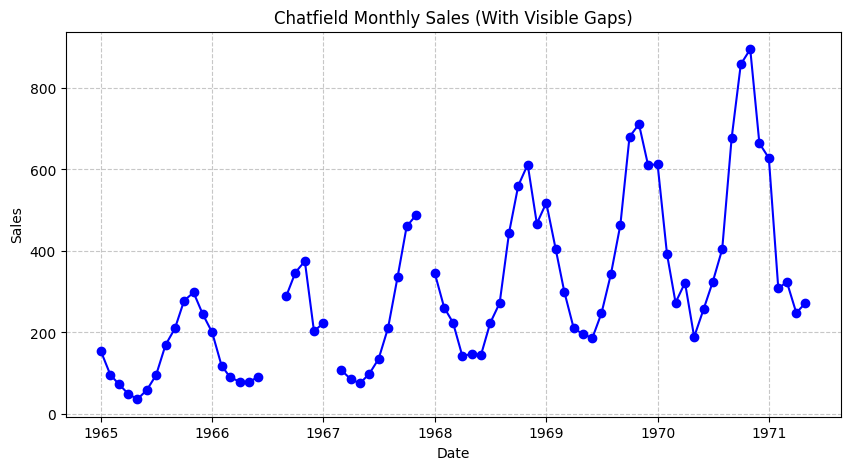

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a complete range of months (no skips)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

# 2. Reindex the dataframe (this inserts the missing months with NaN sales)
df_complete = df.reindex(full_range)

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(df_complete.index, df_complete['sales'], marker='o', linestyle='-', color='b')

plt.title('Chatfield Monthly Sales (With Visible Gaps)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Plot Histogram and Kernel Density Estimate of the sales data

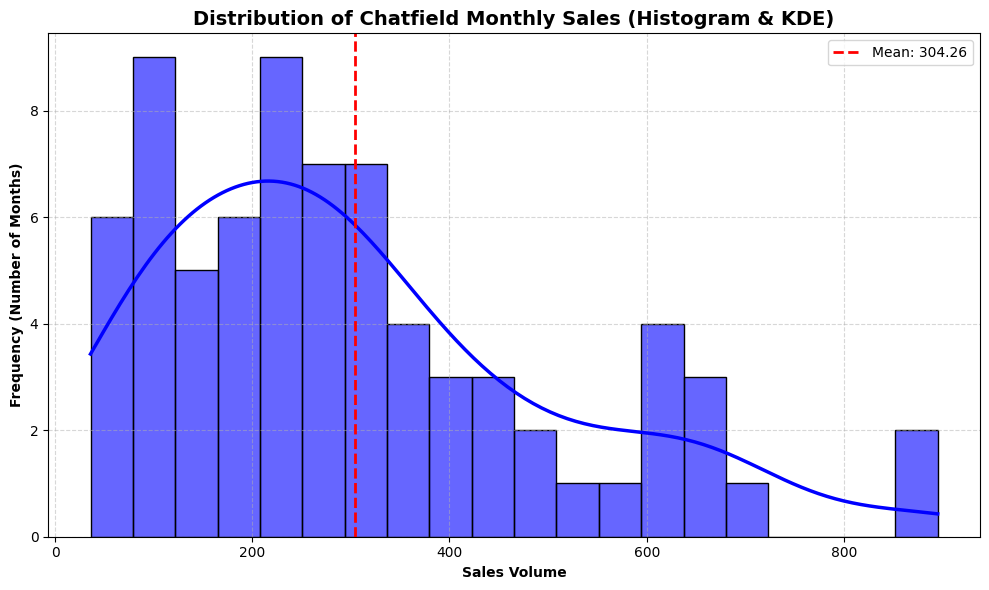

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create the Histogram and KDE with the original data
sns.histplot(df['sales'], 
             bins=20,
             kde=True,
             color='blue',
             alpha=0.6,
             line_kws={'linewidth': 2.5})

# Formatting
plt.title('Distribution of Chatfield Monthly Sales (Histogram & KDE)', fontweight='bold', fontsize=14)
plt.xlabel('Sales Volume', fontweight='bold')
plt.ylabel('Frequency (Number of Months)', fontweight='bold')

# Add a vertical line to show where the Mean is
mean_val = df['sales'].mean()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Box-plot

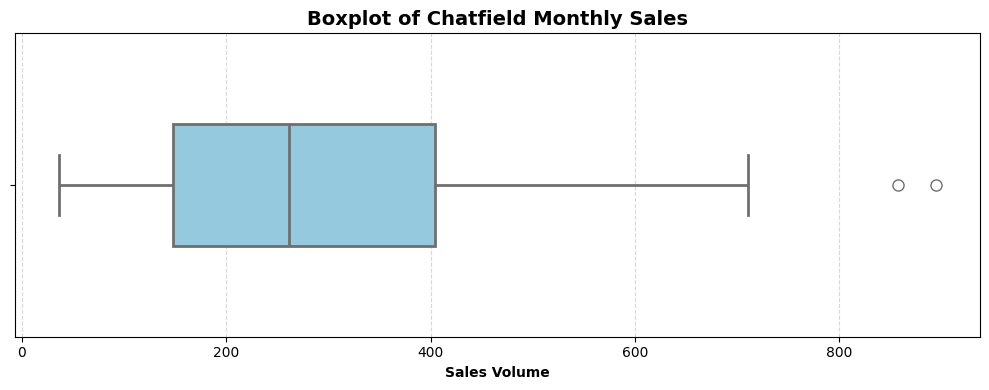

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(10, 4))

# Create the Boxplot (horizontal)
sns.boxplot(x=df_complete['sales'].dropna(), 
            color='skyblue', 
            width=0.4,
            linewidth=2.0,
            fliersize=8)

# Formatting
plt.title('Boxplot of Chatfield Monthly Sales', fontweight='bold', fontsize=14)
plt.xlabel('Sales Volume', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.tight_layout()

plt.show()

Both the histogram and the box-plot reveal a right-skewed distribution with some outliers of very high sales. However, this has to be taken with caution. As we have seen on the raw series, there are not unexpectedly high values, but rather an upward trend coupled with strong seasonality.

### 1.2 Identify and describe key components such as trend, seasonality, cyclical patterns, missing data, outliers.

#### 1.2.1. Identifying the missing data

Count the total number of missing entries

In [78]:
missing_count = df_complete['sales'].isna().sum()
total_months = len(df_complete)
missing_pct = (missing_count / total_months) * 100

print(f"Total missing values: {missing_count} out of {total_months} months ({missing_pct:.2f}%)")

# Show the exact dates of the missing values
print("\nDates with missing data:")
print(df_complete[df_complete['sales'].isna()].index.strftime('%Y-%m').tolist())

Total missing values: 4 out of 77 months (5.19%)

Dates with missing data:
['1966-07', '1966-08', '1967-02', '1967-12']


We have 4 missing observations, which account for ~5% of the dataset. Since the models we will use later require continuous data, we will now analyze which imputation method to apply

**Visual check**

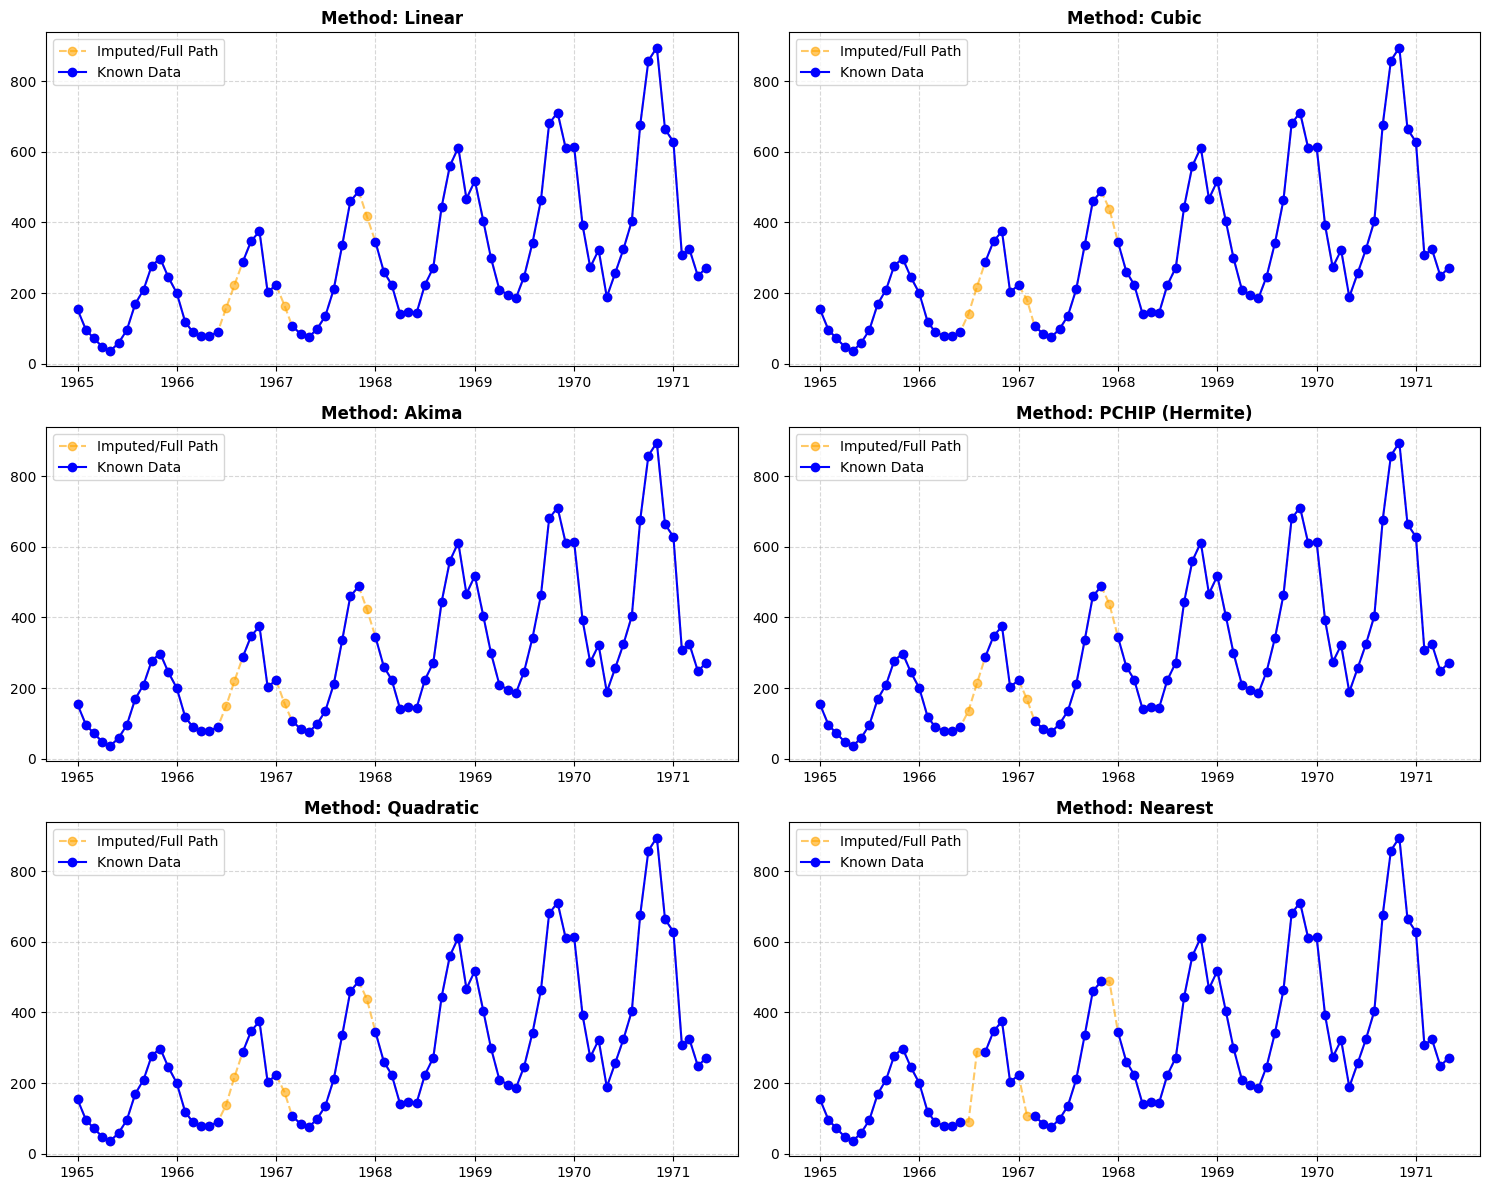

In [79]:
import matplotlib.pyplot as plt

# Expanded list to 6 methods
methods = ['linear', 'cubic', 'akima', 'pchip', 'quadratic', 'nearest']
titles = ['Linear', 'Cubic', 'Akima', 'PCHIP (Hermite)', 'Quadratic', 'Nearest']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, method, title in zip(axes, methods, titles):
    # Calculate imputed values
    imputed_series = df_complete['sales'].interpolate(method=method)
    
    # Plotting
    ax.plot(df_complete.index, imputed_series, marker='o', linestyle='--', 
            color='orange', alpha=0.6, label='Imputed/Full Path')
    ax.plot(df_complete.index, df_complete['sales'], marker='o', linestyle='-', 
            color='b', label='Known Data')
    
    ax.set_title(f"Method: {title}", fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

There's not much difference visually, so we will go straight to the formal test

**Statistical check: Leave-One-Out Validation**

We will follow the following steps to decide on the best interpolation method for our data:

1. Hide a few randomly chosen data points
2. Interpolate those points using different methods
3. Calculate the error against the real values

We will repeat the process for a few iterations and average the results

In [80]:
import numpy as np
import pandas as pd

real_data_indices = df_complete.dropna().index
n_iterations = 100 
n_holes = 5         

# Expanded dictionary
results = {m.capitalize(): [] for m in ['linear', 'cubic', 'akima', 'pchip', 'quadratic', 'nearest']}

for i in range(n_iterations):
    test_indices = np.random.choice(real_data_indices, size=n_holes, replace=False)
    temp_df = df_complete.copy()
    true_values = temp_df.loc[test_indices, 'sales']
    temp_df.loc[test_indices, 'sales'] = np.nan
    
    # Standardizing the series for interpolation
    temp_sales = temp_df['sales'].reset_index(drop=True)
    
    guesses = {
        'Linear':    temp_sales.interpolate(method='linear'),
        'Cubic':     temp_sales.interpolate(method='cubic'),
        'Akima':     temp_sales.interpolate(method='akima'),
        'Pchip':     temp_sales.interpolate(method='pchip'),
        'Quadratic': temp_sales.interpolate(method='quadratic'),
        'Nearest':   temp_sales.interpolate(method='nearest')
    }
    
    for method in results.keys():
        int_positions = [temp_df.index.get_loc(idx) for idx in test_indices]
        method_guesses = guesses[method].iloc[int_positions].values
        iter_errors = np.abs(method_guesses - true_values.values)
        results[method].append(np.mean(iter_errors[~np.isnan(iter_errors)]))

print("\n--- Final Expanded Validation Results (MAE) ---")
final_comparison = {m: np.nanmean(errs) for m, errs in results.items()}
for method, mae in sorted(final_comparison.items(), key=lambda x: x[1]):
    print(f"{method:12}: {mae:.2f} sales units")


--- Final Expanded Validation Results (MAE) ---
Linear      : 42.24 sales units
Akima       : 43.75 sales units
Pchip       : 44.21 sales units
Quadratic   : 49.99 sales units
Cubic       : 54.08 sales units
Nearest     : 72.82 sales units


The Leave-One-Out Cross Validation process confirmed that Akima was the best among the 4 different methods compared, obtaining a Mean Average Error of 41.41 sales. The stability given by its shape-preserving nature due to the local polynomial approach proved to be the most effective for our data. We impute the data using this method

In [81]:
# impute data using best interpolation method
df_imputed = df_complete.interpolate(method='akima')

#### 1.2.2. Identifying the trend

**VISUAL CHECK:** We isolate the long-term trend using a 12-month moving average

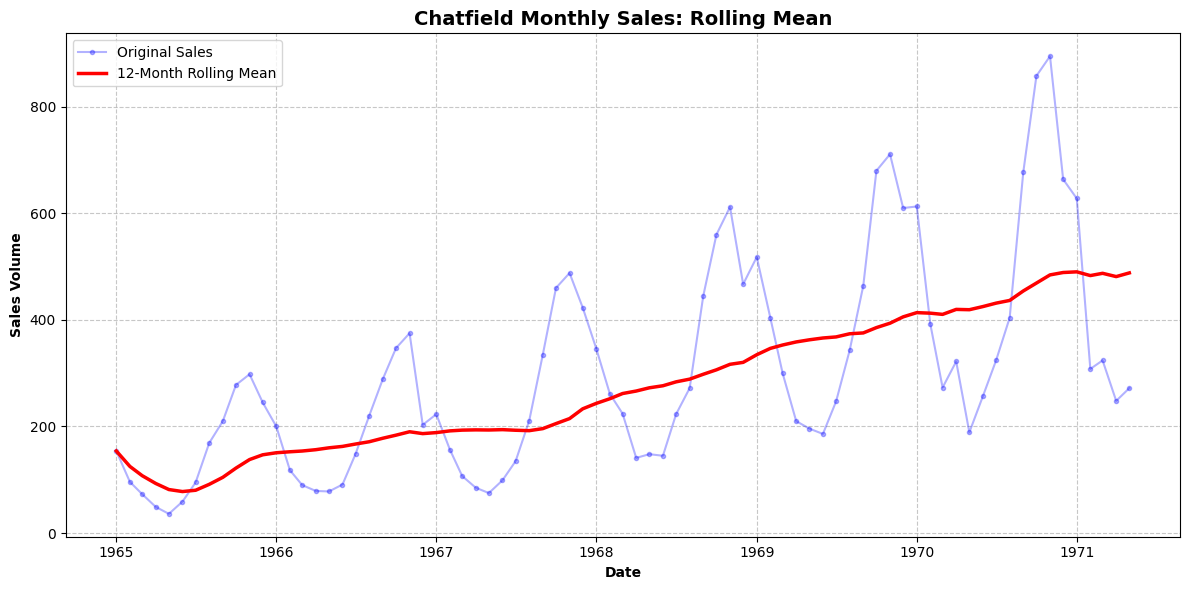

In [82]:
# Define the seasonal window (12 months)
window_size = 12

# Calculate rolling statistics
rolling_mean = df_imputed['sales'].rolling(window=window_size, min_periods=1).mean()
rolling_std = df_imputed['sales'].rolling(window=window_size, min_periods=1).std()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the raw data
plt.plot(df_imputed.index, df_imputed['sales'], label='Original Sales', 
         color='blue', alpha=0.3, marker='.')

# Plot the Rolling Mean (The Trend indicator)
plt.plot(df_imputed.index, rolling_mean, label=f'{window_size}-Month Rolling Mean', 
         color='red', linewidth=2.5)

# Formatting
plt.title('Chatfield Monthly Sales: Rolling Mean', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sales Volume', fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

**FORMAL TEST:** Mann-Kendall non-parametric trend test. If the p-value is smaller than 0.05, we reject the null hypothesis as there is proof that there is a monotonic trend.

In [83]:
import pymannkendall as mk

# Run the Seasonal Mann-Kendall test
# We specify period=12 because we are using monthly data with an annual cycle
mk_result = mk.seasonal_test(df_imputed['sales'], period=12)

# Print the results
print("--- Seasonal Mann-Kendall Trend Test ---")
print(f"Trend direction: {mk_result.trend}")
print(f"p-value:         {mk_result.p:.6f}")
print(f"Z-Score:         {mk_result.z:.4f}")

--- Seasonal Mann-Kendall Trend Test ---
Trend direction: increasing
p-value:         0.000000
Z-Score:         9.2223


The test gives an extremely high Z-Score of 9.22 and hence a significant p-value close to 0, so we definitely reject the null hypothesis of no trend.

#### 1.2.3. Identifying the seasonality

**VISUAL CHECK:** Superposed Seasonal Plot

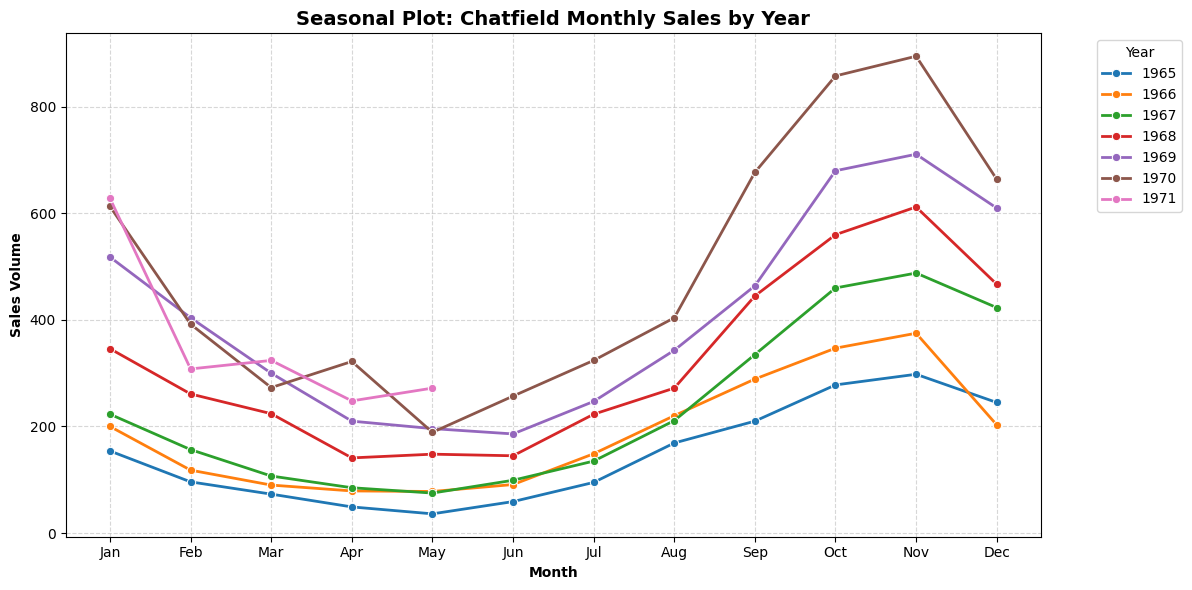

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# 1. Extract Month and Year for the plot
df_imputed['Year'] = df_imputed.index.year
df_imputed['Month'] = df_imputed.index.month

# 2. Create the Superposed Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_imputed, x='Month', y='sales', hue='Year', 
             palette='tab10', marker='o', linewidth=2)

# Formatting
plt.title('Seasonal Plot: Chatfield Monthly Sales by Year', fontweight='bold', fontsize=14)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Sales Volume', fontweight='bold')
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13]) # Uses Jan, Feb, Mar...
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

A superposed seasonal plot was constructed to visually isolate intra-year patterns from the overarching macroeconomic trend. The visualization confirms a rigid, repeating seasonal structure: sales consistently build toward a peak in [insert peak month, e.g., December] and sharply contract in [insert trough month, e.g., January]. The parallel nature of the yearly curves indicates that the seasonality is structurally stable, though the expanding vertical distance between the curves in later years suggests a multiplicative seasonal effect.

**FORMAL TEST:** Autocorrelation (ACF) Plot

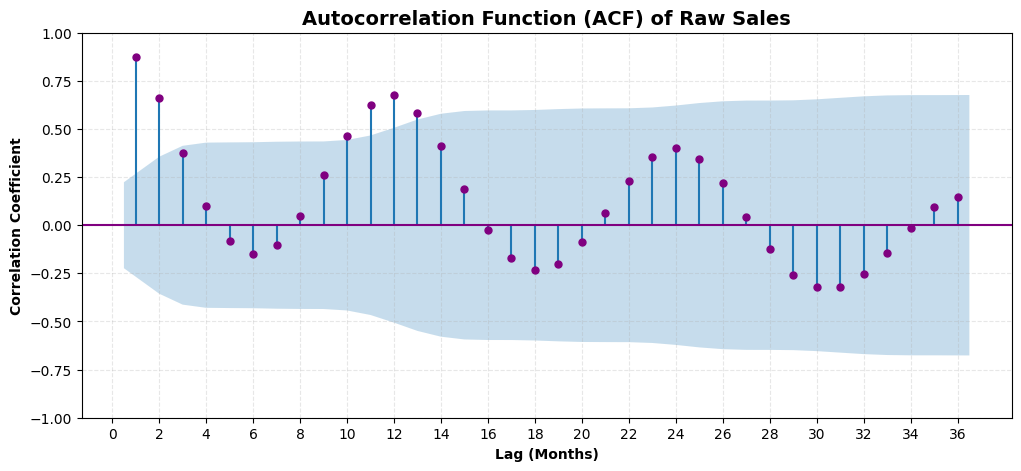

In [85]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
# We look at 36 lags to see exactly 3 full years of history
plot_acf(df_imputed['sales'], lags=36, ax=plt.gca(), color='purple', zero=False)

plt.title('Autocorrelation Function (ACF) of Raw Sales', fontweight='bold', fontsize=14)
plt.xlabel('Lag (Months)', fontweight='bold')
plt.ylabel('Correlation Coefficient', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(range(0, 37, 2))

plt.savefig("acf_raw_sales.png", dpi=300)
plt.show()

We observe positive peaks at lags 12, 24... This indicates a very clear 12-month seasonality.
Also, we observe negative peaks at lags 6, 18, 30... indicating high inverse correlation for a six month lag, for example between December (peak sales) and June (low sales)
In addition, we notice an overall decay in the values in the ACF plot over time, with the positive peaks decreasing in magnitude and the negative peaks increasing. It seems that the series will require both seasonal differencing (D=1) and regular differencing (d=1)

#### 1.2.4. Decomposition

Now that we have seen the presence of trend and seasonal structure, we will visualize both classical and STL decomposition. Even though we only have around 6 years of data, we will use a seasonal smoothing window of 13 (default value) which will help to stabilize the seasonal extraction and prevent overfitting.

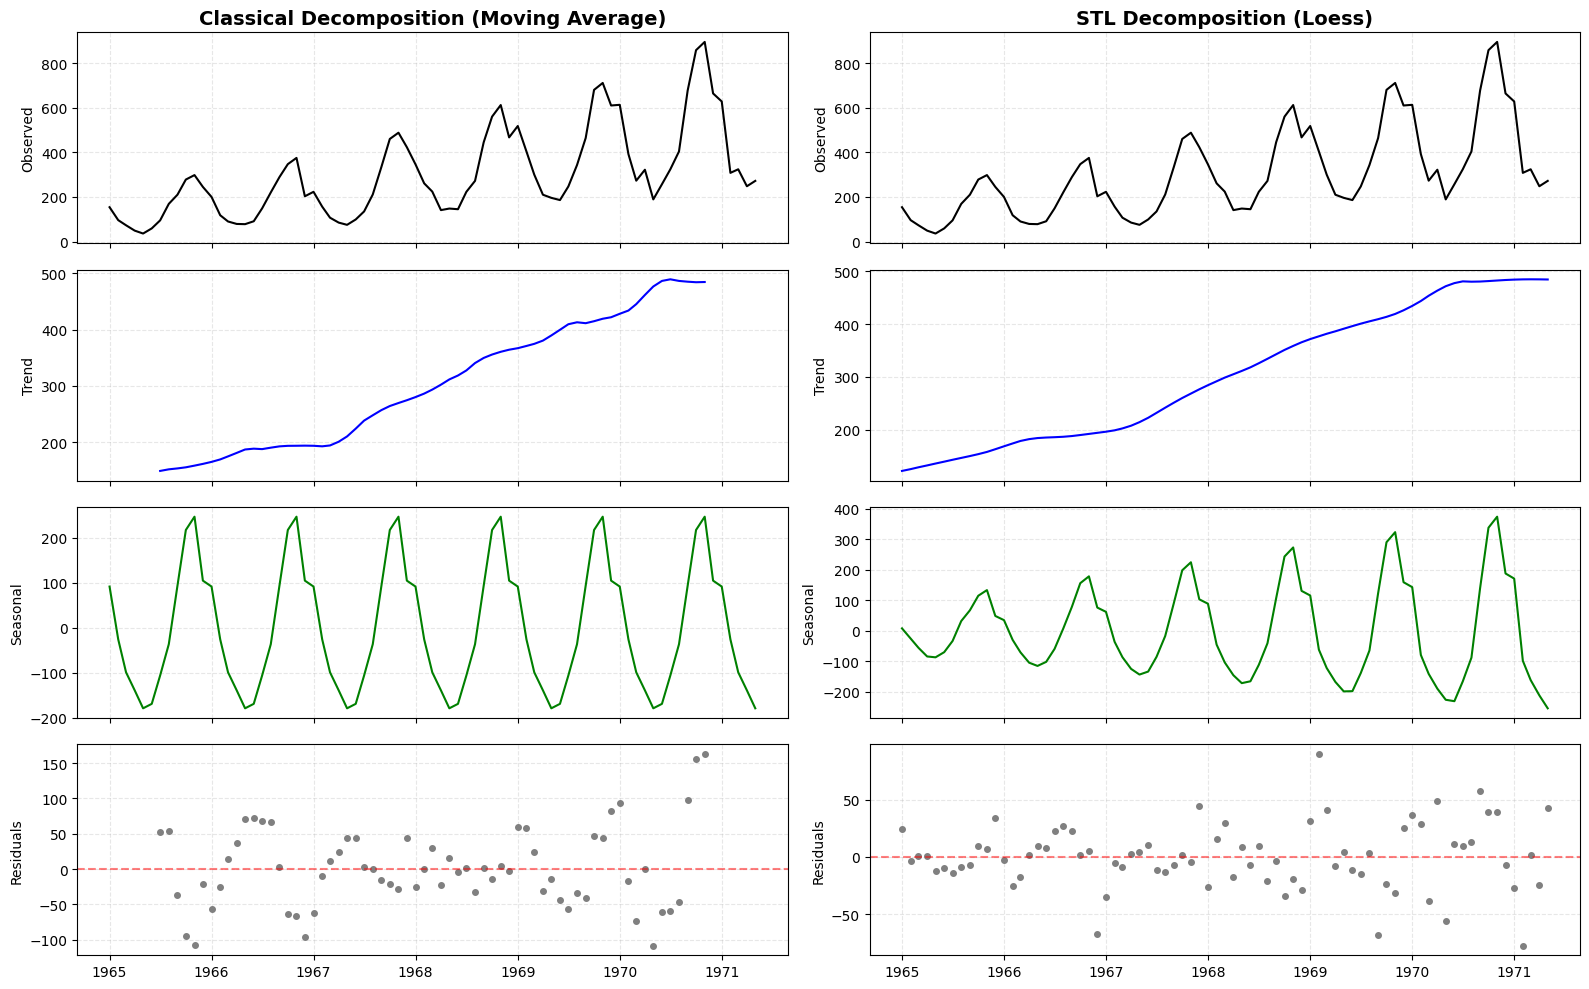

In [86]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# 1. Run Classical Decomposition (Additive)
# period=12 because we have monthly data with a yearly cycle
classical_res = seasonal_decompose(df_imputed['sales'], model='additive', period=12)

# 2. Run STL Decomposition
# seasonal=13 is the default smoothing parameter
stl_res = STL(df_imputed['sales'], period=12, seasonal=13).fit()

# 3. Create a side-by-side comparative plot (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)

# Helper function
def plot_components(res, col_idx, title):
    axes[0, col_idx].plot(df_imputed.index, res.observed, color='black')
    axes[0, col_idx].set_title(title, fontweight='bold', fontsize=14)
    axes[0, col_idx].set_ylabel('Observed')
    
    axes[1, col_idx].plot(df_imputed.index, res.trend, color='blue')
    axes[1, col_idx].set_ylabel('Trend')
    
    axes[2, col_idx].plot(df_imputed.index, res.seasonal, color='green')
    axes[2, col_idx].set_ylabel('Seasonal')
    
    # We use a scatter-style plot for residuals
    axes[3, col_idx].plot(df_imputed.index, res.resid, marker='o', linestyle='none', color='gray', markersize=4)
    axes[3, col_idx].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[3, col_idx].set_ylabel('Residuals')
    
    for i in range(4):
        axes[i, col_idx].grid(True, linestyle='--', alpha=0.3)

# Plot both
plot_components(classical_res, 0, 'Classical Decomposition (Moving Average)')
plot_components(stl_res, 1, 'STL Decomposition (Loess)')

plt.tight_layout()
plt.savefig("classical_vs_stl.png", dpi=300)
plt.show()

The visual comparison shows why STL Decomposition is better than Classical Additive Decomposition for our data.
- It can capture the whole trend without truncation at the beginning and at the end
- It captures the seasonal structure and also the increasing scale, while classical decomposition extracts it as rigid.

Due to capturing the variance better, the residuals of STL decomposition look more like white noise compared to the residuals of Classical decomposition.

#### 1.2.5. Identifying the outliers

We should not apply standard Z-scores to our data because, as we saw in the boxplot in section 1.1, values in December in the last years will be flagged as "outliers" but that is just a result of the evolving trend and structural seasonality. Instead, we will check the IQR (Interquartile Range) only on the residuals, after STL decomposition

--- Residual Outlier Detection ---
Lower Bound: -54.48
Upper Bound: 52.85
Total Anomalies Found: 6

1966-12-01   -66.829517
1969-02-01    89.622770
1969-09-01   -67.692792
1970-05-01   -55.734462
1970-09-01    57.341993
1971-02-01   -77.412264
Name: resid, dtype: float64


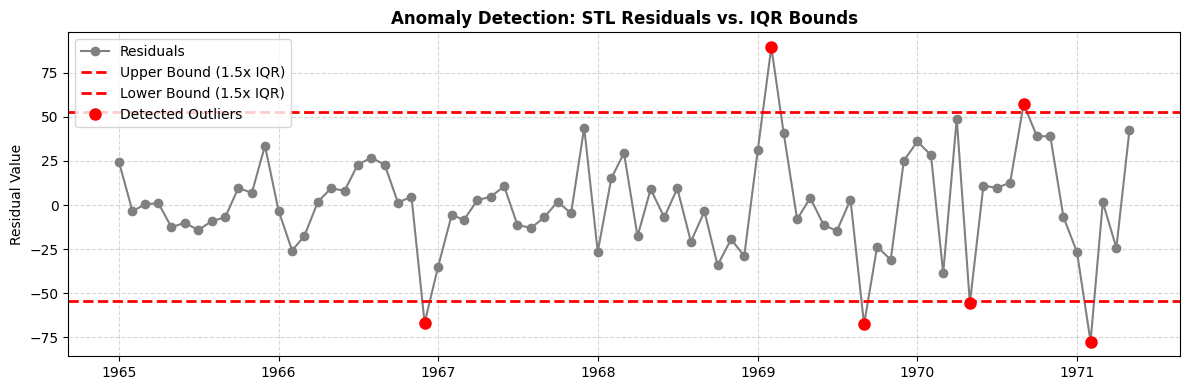

In [87]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# 1. Run the STL Decomposition on the clean, imputed data
# period=12 for annual seasonality. seasonal=13 is the default smoothing window.
stl = STL(df_imputed['sales'], period=12, seasonal=13)
res = stl.fit()

# Extract just the residuals
residuals = res.resid

# 2. Calculate the IQR bounds on those residuals
Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify the exact dates of any outliers
outliers = residuals[(residuals < lower_bound) | (residuals > upper_bound)]

print("--- Residual Outlier Detection ---")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Total Anomalies Found: {len(outliers)}\n")
if len(outliers) > 0:
    print(outliers)

# 4. Plot the residuals
plt.figure(figsize=(12, 4))
plt.plot(residuals.index, residuals, marker='o', linestyle='-', color='gray', label='Residuals')

# Draw the IQR threshold boundaries
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=2, label='Upper Bound (1.5x IQR)')
plt.axhline(lower_bound, color='red', linestyle='--', linewidth=2, label='Lower Bound (1.5x IQR)')

# Highlight the specific outlier dots in red
if len(outliers) > 0:
    plt.plot(outliers.index, outliers, 'ro', markersize=8, label='Detected Outliers')

plt.title('Anomaly Detection: STL Residuals vs. IQR Bounds', fontweight='bold')
plt.ylabel('Residual Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

We will now use the indices on the raw data to see which are the entries that have been flagged as anomalies. We will also visualize the bands outside which values are considered outliers

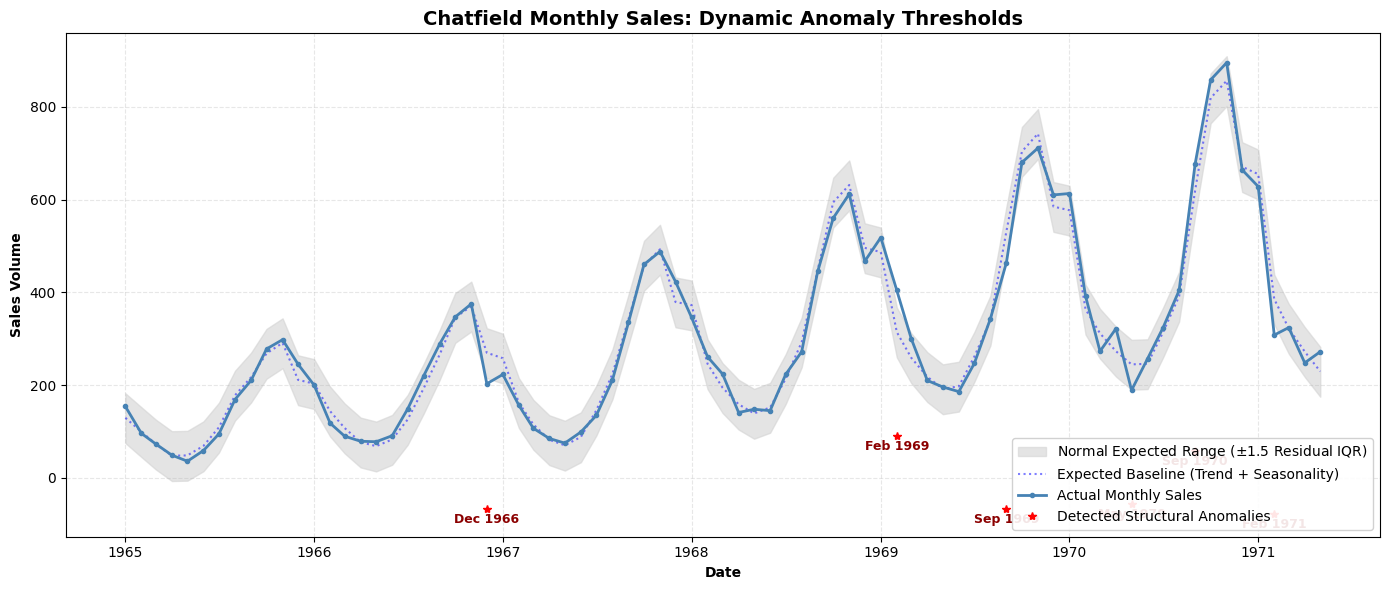

In [88]:
import matplotlib.pyplot as plt

# 1. Reconstruct the expected baseline
expected_baseline = res.trend + res.seasonal

# 2. Create the dynamic upper and lower bands for the raw data
dynamic_lower = expected_baseline + lower_bound
dynamic_upper = expected_baseline + upper_bound

# 3. Create the Plot
plt.figure(figsize=(14, 6))

# Fill the "Normal" band
plt.fill_between(df_imputed.index, dynamic_lower, dynamic_upper, 
                 color='lightgray', alpha=0.6, 
                 label='Normal Expected Range ($\pm 1.5$ Residual IQR)')

# Plot the expected baseline
plt.plot(df_imputed.index, expected_baseline, color='blue', linestyle=':', 
         alpha=0.5, label='Expected Baseline (Trend + Seasonality)')

# Plot the actual raw sales data
plt.plot(df_imputed.index, df_imputed['sales'], marker='.', linestyle='-', 
         color='steelblue', label='Actual Monthly Sales', linewidth=2)

# Highlight the exact outlier dates
plt.plot(outliers.index, outliers, 'r*', markersize=6, 
         label='Detected Structural Anomalies')

# Annotate the outliers with the dates
for date, val in zip(outliers.index, outliers):
    offset = 20 if val > expected_baseline.loc[date] else -30
    plt.text(date, val + offset, date.strftime('%b %Y'), fontsize=9, 
             color='darkred', ha='center', fontweight='bold')

# Formatting
plt.title('Chatfield Monthly Sales: Dynamic Anomaly Thresholds', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sales Volume', fontweight='bold')

# Put legend outside if it gets too crowded, or leave it upper left
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) 
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig("outlier_bands.png", dpi=300)
plt.show()

Even though the IQR method flagged six entries as outliers, following the 1.5 IQR rule, we observe that the deviations are minimal and just a result of natural stochastic noise. We will not apply any treatment on those outliers, as we prioritize keeping the data as raw as possible for better future generalization.

### 1.4 Evaluate the stationarity of the series.

First we will do the same visual check we did to check the existence of a trend (rolling mean) but we will also add the rolling standard deviation. This way we check the first two conditions of weak stationarity: constant mean and constant variance

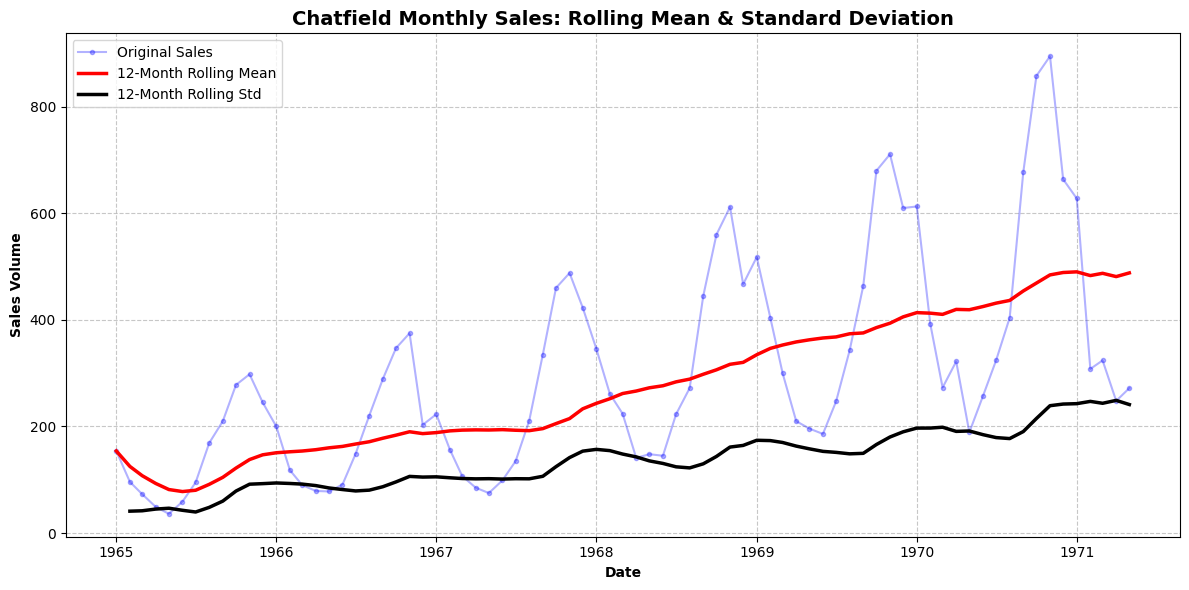

In [89]:
# Define the seasonal window (12 months)
window_size = 12

# Calculate rolling statistics
rolling_mean = df_imputed['sales'].rolling(window=window_size, min_periods=1).mean()
rolling_std = df_imputed['sales'].rolling(window=window_size, min_periods=1).std()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the raw data
plt.plot(df_imputed.index, df_imputed['sales'], label='Original Sales', 
         color='blue', alpha=0.3, marker='.')

# Plot the Rolling Mean (The Trend indicator)
plt.plot(df_imputed.index, rolling_mean, label=f'{window_size}-Month Rolling Mean', 
         color='red', linewidth=2.5)

# Plot the Rolling Standard Deviation (The Volatility/Variance indicator)
plt.plot(df_imputed.index, rolling_std, label=f'{window_size}-Month Rolling Std', 
         color='black', linewidth=2.5)

# Formatting
plt.title('Chatfield Monthly Sales: Rolling Mean & Standard Deviation', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sales Volume', fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Both the mean and the standard deviation clearly increase over time, making it very clear that the process is not stationary. We will use the ADF and KPSS tests for confirmation.

In [90]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore") # Suppress KPSS interpolation warnings

# 1. Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(df_imputed['sales'])
print("--- Augmented Dickey-Fuller (ADF) Test ---")
print(f"Null Hypothesis (H0): The series has a unit root (Non-Stationary)")
print(f"ADF Statistic:  {adf_result[0]:.4f}")
print(f"p-value:        {adf_result[1]:.4f}")
print(f"Result:         {'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")

# 2. KPSS Test
# regression='c' tests for level stationarity. nlags='auto' lets the math find the optimal lags.
kpss_result = kpss(df_imputed['sales'], regression='c', nlags='auto')
print("\n--- KPSS Test ---")
print(f"Null Hypothesis (H0): The series is strictly stationary")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.4f}")
print(f"Result:         {'Stationary' if kpss_result[1] > 0.05 else 'Non-Stationary'}")

--- Augmented Dickey-Fuller (ADF) Test ---
Null Hypothesis (H0): The series has a unit root (Non-Stationary)
ADF Statistic:  0.5899
p-value:        0.9874
Result:         Non-Stationary

--- KPSS Test ---
Null Hypothesis (H0): The series is strictly stationary
KPSS Statistic: 0.8431
p-value:        0.0100
Result:         Non-Stationary


We get very clear, non-ambiguous results from the two tests. We can confidently say the series is non-stationary. We can also visualize based on the p-values how confident we can be in our results.

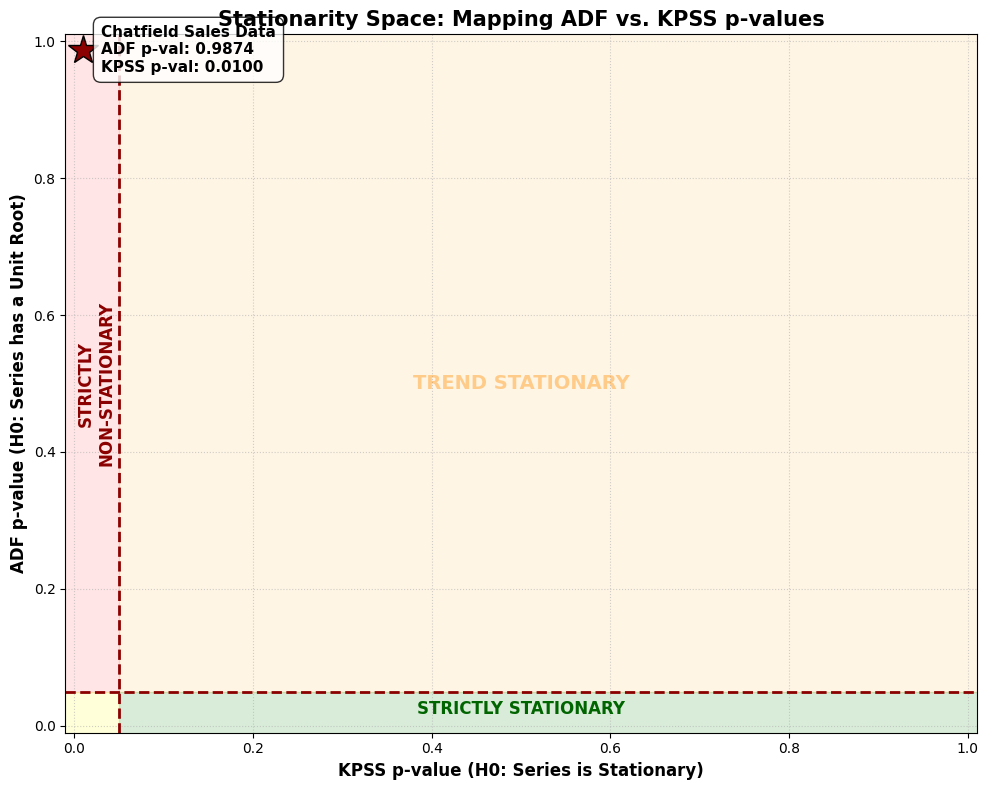

In [91]:
import matplotlib.pyplot as plt

# The actual p-values from the statistical tests
adf_pval = 0.9874
kpss_pval = 0.0100

plt.figure(figsize=(10, 8))

# 1. Shade the 4 Quadrants based on the 0.05 Alpha Thresholds
plt.fill_betweenx([0.05, 1.05], -0.05, 0.05, color='red', alpha=0.10)
plt.fill_betweenx([-0.05, 0.05], 0.05, 1.05, color='green', alpha=0.15)
plt.fill_betweenx([-0.05, 0.05], -0.05, 0.05, color='yellow', alpha=0.15)
plt.fill_betweenx([0.05, 1.05], 0.05, 1.05, color='orange', alpha=0.10)

# 2. Draw the rigid Alpha = 0.05 threshold lines
plt.axvline(x=0.05, color='darkred', linestyle='--', linewidth=2)
plt.axhline(y=0.05, color='darkred', linestyle='--', linewidth=2)

# 3. Plot the specific Chatfield dataset point
plt.plot(kpss_pval, adf_pval, marker='*', markersize=22, color='darkred', 
         markeredgecolor='black')

# 4. Annotate the point so the exact math and the name are visible together
plt.text(kpss_pval + 0.02, adf_pval, 
         f"Chatfield Sales Data\nADF p-val: {adf_pval:.4f}\nKPSS p-val: {kpss_pval:.4f}", 
         fontsize=11, fontweight='bold', va='center', ha='left',
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8, boxstyle='round,pad=0.5'))

# 5. Add quadrant background labels
plt.text(0.025, 0.5, 'STRICTLY\nNON-STATIONARY', 
         ha='center', va='center', fontsize=12, fontweight='bold', color='darkred', rotation=90)
plt.text(0.5, 0.025, 'STRICTLY STATIONARY', 
         ha='center', va='center', fontsize=12, fontweight='bold', color='darkgreen')
plt.text(0.5, 0.5, 'TREND STATIONARY', 
         ha='center', va='center', fontsize=14, fontweight='bold', color='darkorange', alpha=0.4)

# Formatting
plt.title('Stationarity Space: Mapping ADF vs. KPSS p-values', fontsize=15, fontweight='bold')
plt.xlabel('KPSS p-value (H0: Series is Stationary)', fontsize=12, fontweight='bold')
plt.ylabel('ADF p-value (H0: Series has a Unit Root)', fontsize=12, fontweight='bold')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

## 2. Data preprocessing

### 2.1. Process the data as necessary based on your descriptive analysis. Justify why each preprocessing step was taken

#### 2.1.1 Train/test split

To prevent leakage and prevent over-optimistic forecasts, we do a simple chronological train/test split. We hold the last 12 months of the dataset (one seasonal cycle as per our previous analysis) for testing, and use the first 65 months for training.

In [92]:
# 1. Define the size of the holdout set (12 months = 1 full seasonal cycle)
test_size = 12

# 2. Perform the strict chronological split
# We use .copy() to ensure these become independent dataframes
train_data = df_imputed.iloc[:-test_size].copy()
test_data = df_imputed.iloc[-test_size:].copy()

# 3. Verify the split chronologically
print("--- Chronological Train/Test Split ---")
print(f"Total Observations: {len(df_imputed)} months")
print(f"Training Set:       {len(train_data)} months ({train_data.index.min().strftime('%b %Y')} to {train_data.index.max().strftime('%b %Y')})")
print(f"Testing Set:        {len(test_data)} months ({test_data.index.min().strftime('%b %Y')} to {test_data.index.max().strftime('%b %Y')})")

--- Chronological Train/Test Split ---
Total Observations: 77 months
Training Set:       65 months (Jan 1965 to May 1970)
Testing Set:        12 months (Jun 1970 to May 1971)


#### 2.1.1. Variance stabilization

This is the first step we need to take to achieve stationarity. We will apply a mathematical transformation to make the spread consistent across time.

We will, in principle, use the Box-Cox method as it can be optimized from the data. However, depending on the value of λ we might be able to use a simpler transformation and obtain similar results.

In [93]:
import numpy as np
from scipy.stats import boxcox
from scipy.optimize import minimize_scalar

# 1. MLE Method
# We calculate this strictly on the training set to prevent data leakage
_, lambda_mle = boxcox(train_data['sales'])

# 2. Guerrero Method (Custom implementation for seasonal blocks)
def guerrero_objective(lam, y, period):
    """
    Minimizes the Coefficient of Variation of the block variances.
    """
    # Split the data into blocks of 12 months (period)
    n = len(y)
    num_blocks = n // period
    y_trunc = y[:num_blocks * period] # Drop remainder to make even blocks
    blocks = y_trunc.reshape(num_blocks, period)
    
    # Calculate the mean and standard deviation of each year
    means = np.mean(blocks, axis=1)
    stds = np.std(blocks, axis=1, ddof=1)
    
    # The Guerrero metric: std / mean^(1-lambda)
    ratios = stds / (means ** (1 - lam))
    
    # We want the variance of these ratios to be as close to 0 as possible
    return np.std(ratios, ddof=1) / np.mean(ratios)

# Find the lambda (between -2 and 2) that minimizes the Guerrero objective
res = minimize_scalar(guerrero_objective, bounds=(-2, 2), method='bounded', 
                      args=(train_data['sales'].values, 12))
lambda_guerrero = res.x

# Print the comparison
print("--- Variance Stabilization (Box-Cox Lambda) ---")
print(f"Optimal Lambda (MLE Method):      {lambda_mle:.4f}")
print(f"Optimal Lambda (Guerrero Method): {lambda_guerrero:.4f}")

--- Variance Stabilization (Box-Cox Lambda) ---
Optimal Lambda (MLE Method):      0.2291
Optimal Lambda (Guerrero Method): 0.2811


The λ we obtained seems to be "in the middle of nowhere". We are not close enough to 0 to be confident in applying logarithmic transformation, and not close enough to 0.5 to apply square root transformation. Nonetheless, we will plot the rolling standard deviation resulting from those transformations next to the one resulting from the Box-Cox method and decide.

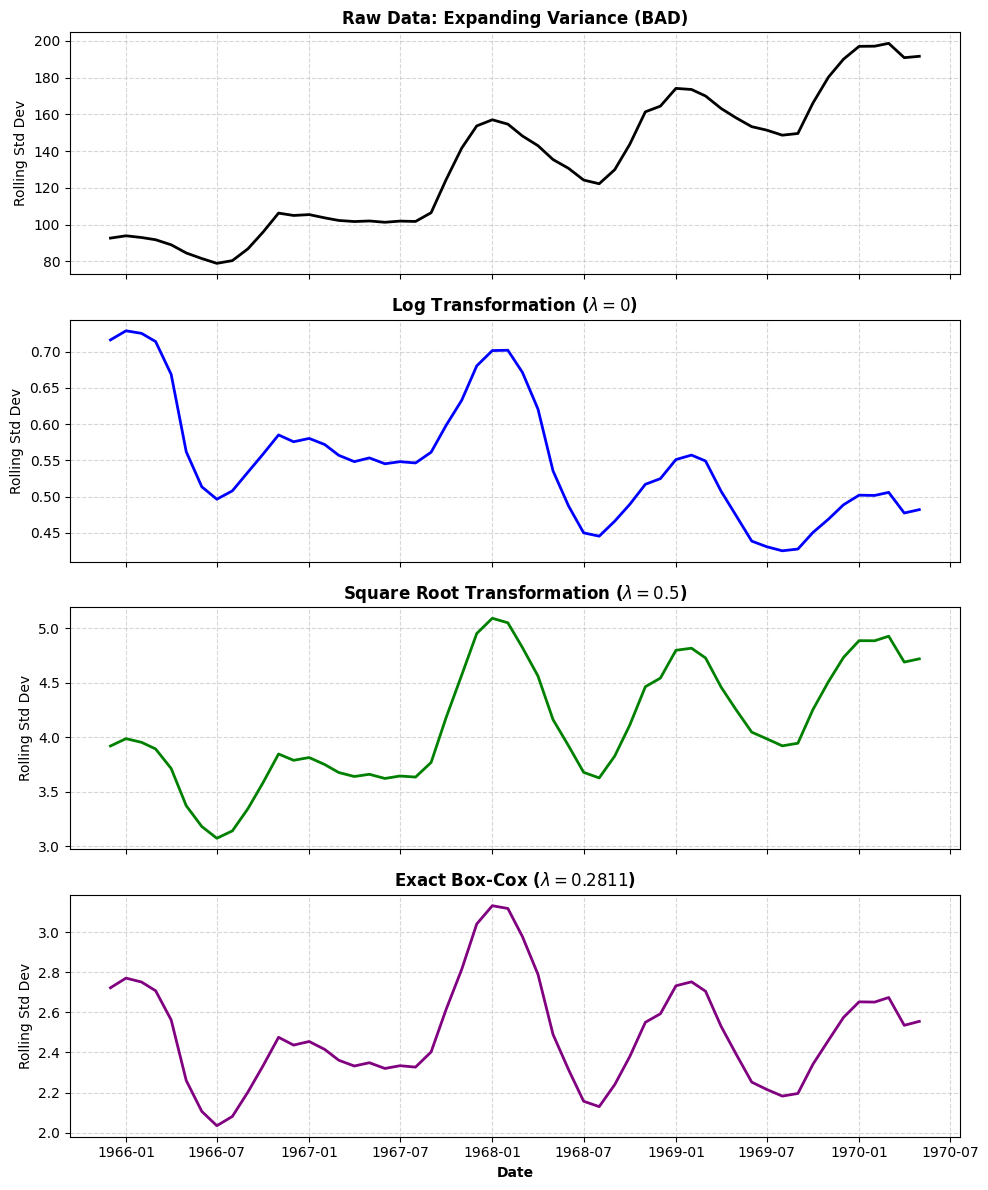

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

window = 12

# 1. Apply the three transformations to the training data
train_log = np.log(train_data['sales'])                            # Lambda = 0
train_sqrt = np.sqrt(train_data['sales'])                          # Lambda = 0.5
train_exact = boxcox(train_data['sales'], lmbda=lambda_guerrero)   # Lambda = 0.2811
train_exact = pd.Series(train_exact, index=train_data.index)       # Convert back to Pandas Series

# 2. Calculate the rolling standard deviations
roll_std_raw = train_data['sales'].rolling(window=window).std()
roll_std_log = train_log.rolling(window=window).std()
roll_std_sqrt = train_sqrt.rolling(window=window).std()
roll_std_exact = train_exact.rolling(window=window).std()

# 3. Create a 4-panel comparison plot
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

axes[0].plot(roll_std_raw, color='black', linewidth=2)
axes[0].set_title('Raw Data: Expanding Variance (BAD)', fontweight='bold')

axes[1].plot(roll_std_log, color='blue', linewidth=2)
axes[1].set_title('Log Transformation ($\lambda = 0$)', fontweight='bold')

axes[2].plot(roll_std_sqrt, color='green', linewidth=2)
axes[2].set_title('Square Root Transformation ($\lambda = 0.5$)', fontweight='bold')

axes[3].plot(roll_std_exact, color='purple', linewidth=2)
axes[3].set_title(f'Exact Box-Cox ($\lambda = {lambda_guerrero:.4f}$)', fontweight='bold')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel('Rolling Std Dev')

plt.xlabel('Date', fontweight='bold')
plt.tight_layout()
plt.savefig("stable_var.png", dpi=300)
plt.show()

We confirm what we expected. 
- The log transformation over-corrects the variance, reducing it in later years
- The square root transformation under-corrects the variance.
- The Box-Cox transformation stabilizes the rolling variance, achieving homoscedasticity.

Even if classical transformations offer better interpretability, the difference in precision makes us choose to apply Box-Cox transformation.

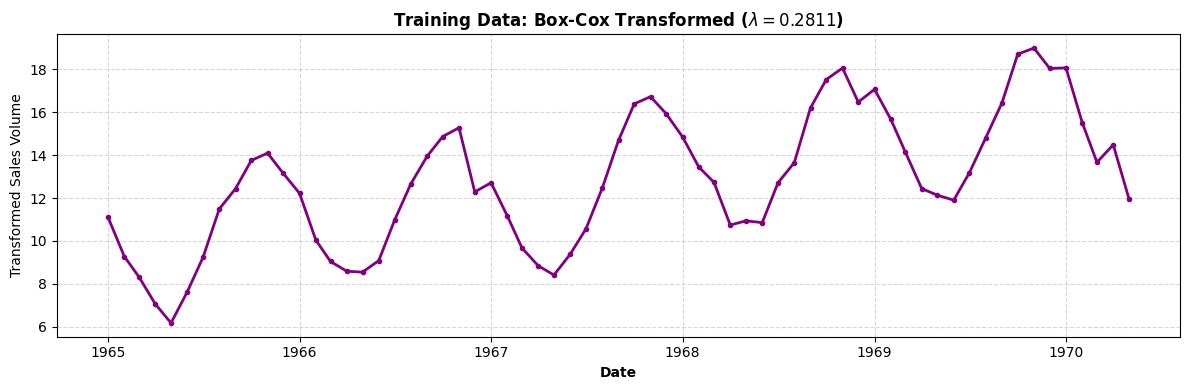

In [95]:
from scipy.special import boxcox
import matplotlib.pyplot as plt

# 1. Apply the Guerrero lambda to the Training Set
train_data['sales_boxcox'] = boxcox(train_data['sales'], lambda_guerrero)

# 2. Apply the EXACT SAME lambda to the Testing Set (Crucial to prevent data leakage!)
test_data['sales_boxcox'] = boxcox(test_data['sales'], lambda_guerrero)

# 3. Quick visual verification of the newly stabilized training data
plt.figure(figsize=(12, 4))
plt.plot(train_data.index, train_data['sales_boxcox'], color='purple', linewidth=2, marker='.')
plt.title(f'Training Data: Box-Cox Transformed ($\lambda = {lambda_guerrero:.4f}$)', fontweight='bold')
plt.ylabel('Transformed Sales Volume')
plt.xlabel('Date', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

#### 2.1.2. Mean stabilization

Now we are going to manually difference the data to find the parameters that lead towards constant mean. We plot the ACF and PACF on each step to guide the parameter selection.

First we will visualize the ACF and PACF for our data after we have stabilized the variance by means of the Box-Cox transformation.

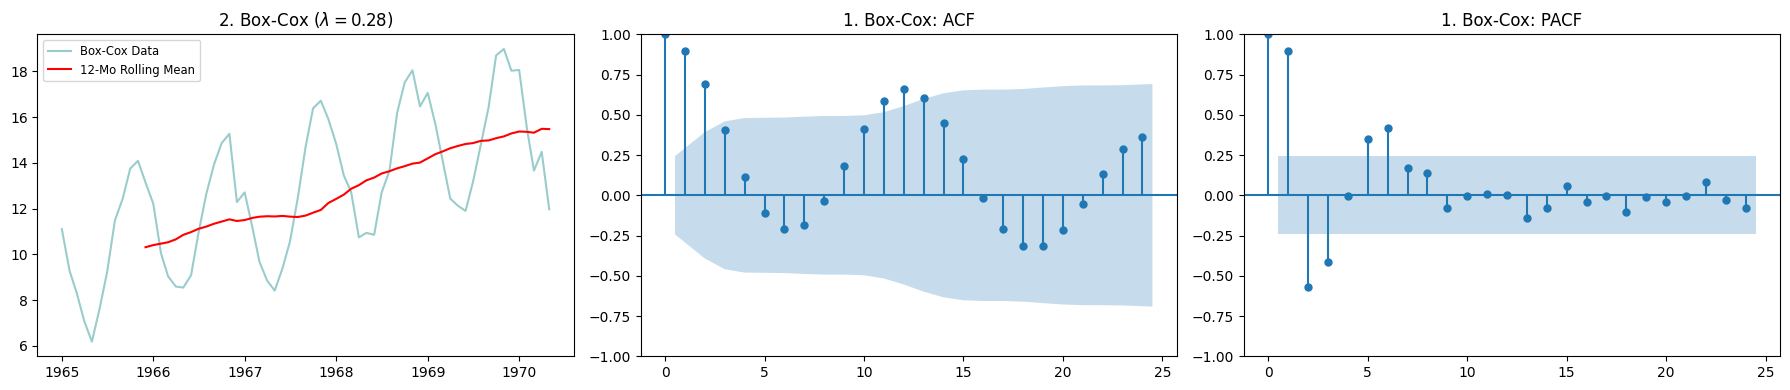

--- Statistics for Step 1 (Box-Cox) ---
ADF p-value:  0.9208 (NON-STATIONARY)
KPSS p-value: 0.0100 (NON-STATIONARY)
Conclusion: Series is definitely non-stationary.


In [96]:
from statsmodels.graphics.tsaplots import plot_pacf

# Stage 1: Box-Cox Transformed
s1 = train_data['sales_boxcox']

# Calculate rolling mean for visual evidence of non-stationarity
rolling_mean_s1 = s1.rolling(window=12).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Column 1: Time Series + Rolling Mean
axes[0].plot(s1, color='teal', alpha=0.4, label='Box-Cox Data')
axes[0].plot(rolling_mean_s1, color='red', label='12-Mo Rolling Mean')
axes[0].set_title(f"2. Box-Cox ($\lambda={lambda_guerrero:.2f}$)")
axes[0].legend(loc='upper left', fontsize='small')

# Column 2 & 3: ACF and PACF
plot_acf(s1, ax=axes[1], lags=24, title="1. Box-Cox: ACF")
plot_pacf(s1, ax=axes[2], lags=24, title="1. Box-Cox: PACF")

plt.tight_layout()
plt.show()

# Calculate p-values
adf_p = adfuller(s1)[1]
kpss_p = kpss(s1, regression='c', nlags='auto')[1]

# Interpretations
adf_res = "STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"
kpss_res = "STATIONARY" if kpss_p > 0.05 else "NON-STATIONARY"

print(f"--- Statistics for Step 1 (Box-Cox) ---")
print(f"ADF p-value:  {adf_p:.4f} ({adf_res})")
print(f"KPSS p-value: {kpss_p:.4f} ({kpss_res})")

if adf_res == "STATIONARY" and kpss_res == "STATIONARY":
    print("Conclusion: Confirmatory Stationarity achieved.")
elif adf_res == "NON-STATIONARY" and kpss_res == "NON-STATIONARY":
    print("Conclusion: Series is definitely non-stationary.")
else:
    print("Conclusion: Conflicting results. Further differencing may be required.")

The rising rolling mean and slow decay in the ACF plot, in addition to the conclusive results of the ADF and KPSS tests suggest that differencing is needed to stabilize the mean. As we see a spike at lag 12 in the ACF plot, we will first apply seasonal differencing before considering regular differencing.

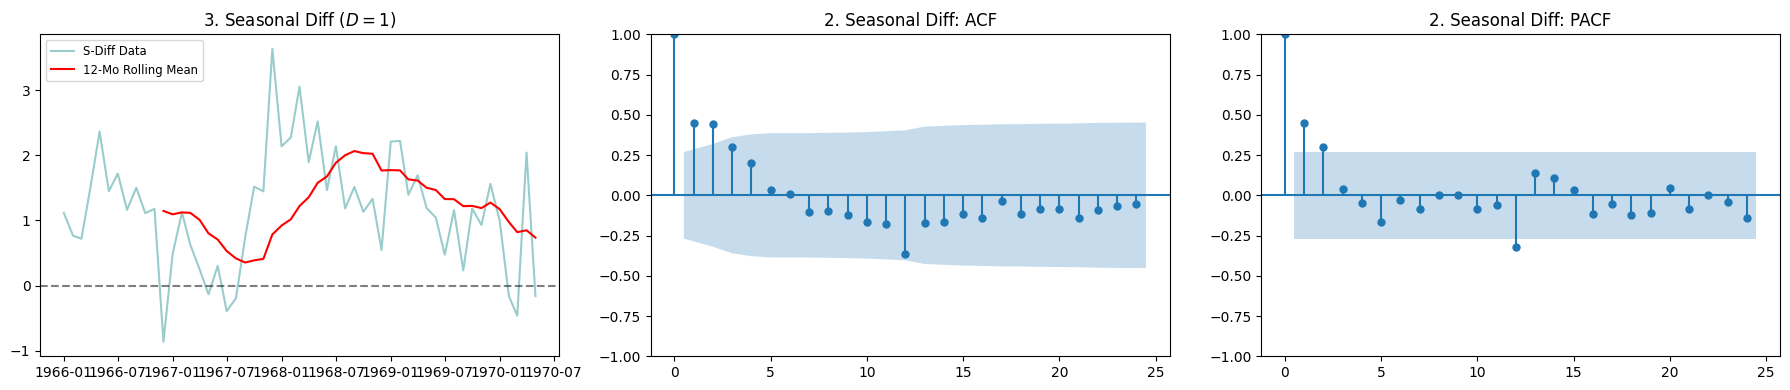

--- Statistics for Step 2 (Seasonal Difference) ---
ADF p-value:  0.0947 (NON-STATIONARY)
KPSS p-value: 0.1000 (STATIONARY)
Conclusion: Conflicting results. Further regular differencing (d=1) is required.


In [97]:
# Stage 2: Seasonal Difference (D=1)
s2 = s1.diff(12).dropna()

# Calculate rolling mean to check for remaining trend
rolling_mean_s2 = s2.rolling(window=12).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Column 1: Time Series + Rolling Mean
axes[0].plot(s2, color='teal', alpha=0.4, label='S-Diff Data')
axes[0].plot(rolling_mean_s2, color='red', label='12-Mo Rolling Mean')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5) # Reference line at 0
axes[0].set_title("3. Seasonal Diff ($D=1$)")
axes[0].legend(loc='upper left', fontsize='small')

# Column 2 & 3: ACF and PACF
plot_acf(s2, ax=axes[1], lags=24, title="2. Seasonal Diff: ACF")
plot_pacf(s2, ax=axes[2], lags=24, title="2. Seasonal Diff: PACF")

plt.tight_layout()
plt.show()

# Calculate p-values
adf_p = adfuller(s2)[1]
kpss_p = kpss(s2, regression='c', nlags='auto')[1]

# Interpretations
adf_res = "STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"
kpss_res = "STATIONARY" if kpss_p > 0.05 else "NON-STATIONARY"

print(f"--- Statistics for Step 2 (Seasonal Difference) ---")
print(f"ADF p-value:  {adf_p:.4f} ({adf_res})")
print(f"KPSS p-value: {kpss_p:.4f} ({kpss_res})")

if adf_res == "STATIONARY" and kpss_res == "STATIONARY":
    print("Conclusion: Confirmatory Stationarity achieved.")
elif adf_res == "NON-STATIONARY" and kpss_res == "NON-STATIONARY":
    print("Conclusion: Series is definitely non-stationary.")
else:
    print("Conclusion: Conflicting results. Further regular differencing (d=1) is required.")

After seasonal differencing, the spike at Lag 12 in the ACF was eliminated. However, the mean still does not seem to be constant at sight. The normality tests now provide conflicting results regarding stationarity. The presence of a few significant spikes at early lags both on the ACF and PACF suggest that there is still some differencing needed. We will apply a regular difference (d=1)

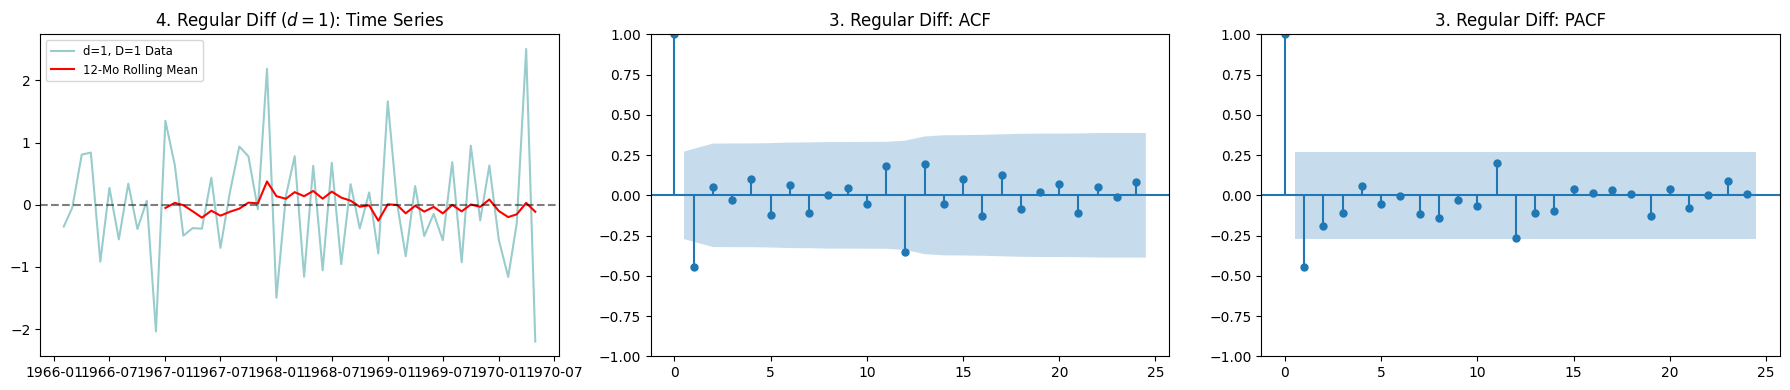

--- Statistics for Step 3 (Final Stationarity) ---
ADF p-value:  0.0000 (STATIONARY)
KPSS p-value: 0.1000 (STATIONARY)
Conclusion: Confirmatory Stationarity achieved.


In [98]:
# Stage 3: Regular Difference (d=1)
s3 = s2.diff(1).dropna()

# Calculate rolling mean to prove stationarity
rolling_mean_s3 = s3.rolling(window=12).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Column 1: Time Series + Rolling Mean
axes[0].plot(s3, color='teal', alpha=0.4, label='d=1, D=1 Data')
axes[0].plot(rolling_mean_s3, color='red', label='12-Mo Rolling Mean')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title("4. Regular Diff ($d=1$): Time Series")
axes[0].legend(loc='upper left', fontsize='small')

# Column 2 & 3: ACF and PACF
plot_acf(s3, ax=axes[1], lags=24, title="3. Regular Diff: ACF")
plot_pacf(s3, ax=axes[2], lags=24, title="3. Regular Diff: PACF")

plt.tight_layout()
plt.show()

# Calculate p-values
adf_p = adfuller(s3)[1]
kpss_p = kpss(s3, regression='c', nlags='auto')[1]

# Interpretations
adf_res = "STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"
kpss_res = "STATIONARY" if kpss_p > 0.05 else "NON-STATIONARY"

print(f"--- Statistics for Step 3 (Final Stationarity) ---")
print(f"ADF p-value:  {adf_p:.4f} ({adf_res})")
print(f"KPSS p-value: {kpss_p:.4f} ({kpss_res})")

if adf_res == "STATIONARY" and kpss_res == "STATIONARY":
    print("Conclusion: Confirmatory Stationarity achieved.")
elif adf_res == "NON-STATIONARY" and kpss_res == "NON-STATIONARY":
    print("Conclusion: Series is definitely non-stationary.")
else:
    print("Conclusion: Conflicting results. Re-check for over-differencing.")

After applying regular differencing on top of seasonal differencing (d=1, D=1) we achieved confirmed stationarity, first visually (12-month rolling window centered at 0) and then confirmed by the ADF and KPSS tests. We have now stabilized the mean, removing completely the trend. But even after manually doing seasonal differencing we can still see significant negative spikes at Lag 1 and Lag 12 on the ACF plot, indicating seasonal memory that should be modeled by a seasonal-aware model like SARIMA (q=1, Q=1, s=12) and that seasonality-unaware models like ARIMA should be avoided. Based on the sharp cutoffs at Lag 1 and Lag 12 in the PACF, the data seems to be more dominated by the moving average components. Since it is not fully clear, we will two different configurations for the AR parameters: (p=0, P=0) [simpler, avoid unnecessary complexity] and (p=1, P=1) [potentially capture more information]

## 3. MODEL SELECTION AND FITTING

### 3.1 Evaluate differente statistical models (ARIMA, SARIMA, ARCH, GARCH) to determine the best fit for your specific dataset

In [99]:
import statsmodels.api as sm
import pandas as pd

# 1. Native SARIMA Models (Using Box-Cox data, internal d=1, D=1)
model_sarima_a = sm.tsa.statespace.SARIMAX(train_data['sales_boxcox'], 
                                           order=(0, 1, 1), 
                                           seasonal_order=(0, 1, 1, 12)).fit(disp=False)

model_sarima_c = sm.tsa.statespace.SARIMAX(train_data['sales_boxcox'], 
                                           order=(1, 1, 1), 
                                           seasonal_order=(1, 1, 1, 12)).fit(disp=False)

# 2. Manual ARIMA
# We use order (0,0,1) because the 's3' is already differenced
model_manual_arima = sm.tsa.ARIMA(s3, order=(0, 0, 1)).fit()

# 3. Model Selection Table
selection_results = {
    "SARIMA(0,1,1)(0,1,1)12": [model_sarima_a.aic, model_sarima_a.bic],
    "SARIMA(1,1,1)(1,1,1)12": [model_sarima_c.aic, model_sarima_c.bic],
    "Manual ARIMA(0,1,1)": [model_manual_arima.aic, model_manual_arima.bic]
}

df_results = pd.DataFrame(selection_results, index=['AIC', 'BIC']).T
print("--- Model Selection Tournament ---")
print(df_results.sort_values('AIC'))

--- Model Selection Tournament ---
                               AIC         BIC
SARIMA(0,1,1)(0,1,1)12  122.469833  128.323564
SARIMA(1,1,1)(1,1,1)12  126.046987  135.803206
Manual ARIMA(0,1,1)     131.288356  137.142087


### 3.2. Outline your selection criteria and explain the rationale behind choosing your final model parameters over the alternatives

- We chose the SARIMA(0,1,1)(0,1,1)12 configuration as it has the best results both in Akaike Information Criteria and Bayesian Information Criteria, being the best balance between simplicity and performance.

- We confirm our hypothesis that SARIMA was a better choice than ARIMA considering the seasonal memory.

- We decided not to try ARCH / GARCH models because they are specialized on data with stochastic volatility and variance clustering, where the variance changes independently of the level, having regions of stable variance followed by abrupt changes. In our problem, the variance seems to depend on the level of the series, which is typical with multiplicative seasonality. Furthermore, we were also able to stabilize it with Box-Cox transformation.

## 4. Model validation and predictive quality

### 4.1. Perform diagnostic checks on the model to ensure the model's assumptions are met

We perform residual analysis

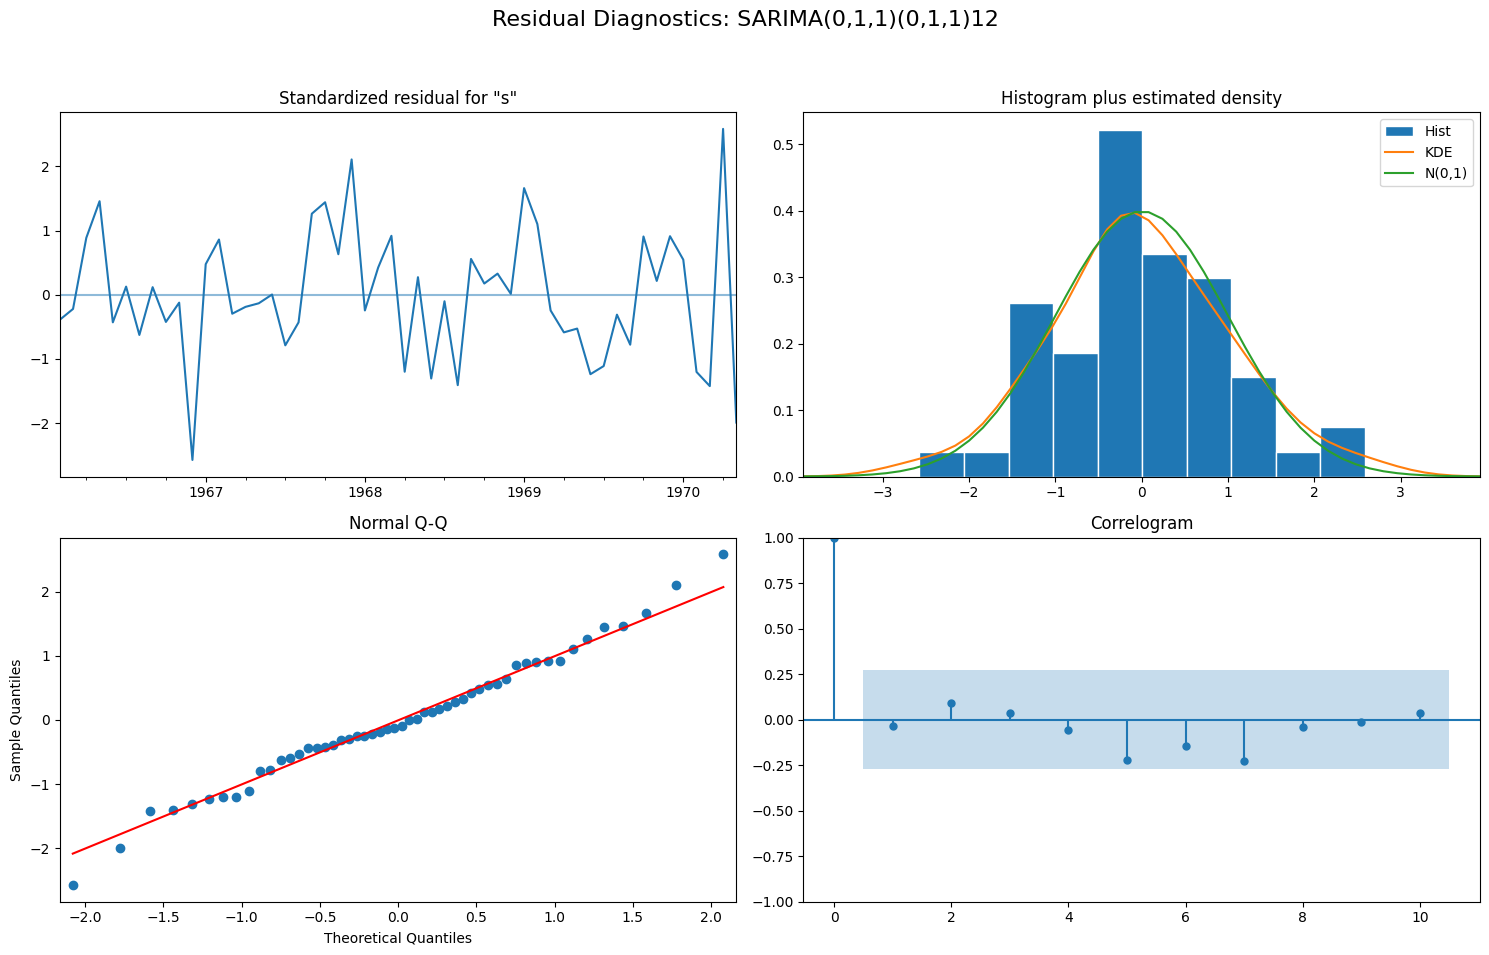

--- Formal Diagnostic Tests ---
Shapiro-Wilk p-value: 0.0000
Ljung-Box p-value:    0.6607
------------------------------
Residuals are not normally distributed.
Residuals are White Noise.


In [100]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

# 1. Standard Diagnostic Plots
fig = model_sarima_a.plot_diagnostics(figsize=(15, 10))
plt.suptitle("Residual Diagnostics: SARIMA(0,1,1)(0,1,1)12", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Formal Statistical Tests
res = model_sarima_a.resid

# Shapiro-Wilk Test for Normality
stat_shapiro, p_shapiro = shapiro(res)

# Ljung-Box Test for Autocorrelation (Lag = 2*m = 24 for seasonal data)
lb_test = acorr_ljungbox(res, lags=[24], return_df=True)

# --- Formal Diagnostic Tests ---
print(f"--- Formal Diagnostic Tests ---")
print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}")
print(f"Ljung-Box p-value:    {lb_test['lb_pvalue'].values[0]:.4f}")
print("-" * 30)

# 1. Normality (Shapiro-Wilk)
if p_shapiro > 0.05:
    print("Residuals are normally distributed.")
else:
    print("Residuals are not normally distributed.")

# 2. Independence (Ljung-Box)
if lb_test['lb_pvalue'].values[0] > 0.05:
    print("Residuals are White Noise.")
else:
    print("Significant autocorrelation remains.")

The residuals do not follow a strict normal distribution according to the Shapiro-Wilk test even though the histogram looks quite normal and symmetric. But most importantly, the residuals are independent from each other, so they are still considered white noise.

### 4.2. Evaluate the forecasting performance of your model using appropriate metrics and validation scheme.

Use Naive models as baseline

In [101]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error as mape
import pandas as pd
import numpy as np

# 1. Convert indices to PeriodIndex ('M' for Month) to satisfy sktime
y_train = train_data['sales'].to_period("M")
y_test = test_data['sales'].to_period("M")

# Define the 12-month horizon
fh = np.arange(1, 13)

# 2. Run the Baselines
# Naive (Last)
f_last = NaiveForecaster(strategy="last")
f_last.fit(y_train)
pred_last = f_last.predict(fh)

# Naive Mean
f_mean = NaiveForecaster(strategy="mean")
f_mean.fit(y_train)
pred_mean = f_mean.predict(fh)

# Naive Drift
f_drift = NaiveForecaster(strategy="drift")
f_drift.fit(y_train)
pred_drift = f_drift.predict(fh)

# Seasonal Naive (sp=12)
f_snaive = NaiveForecaster(strategy="last", sp=12)
f_snaive.fit(y_train)
pred_snaive = f_snaive.predict(fh)

# 3. Seasonal Naive with Drift
drift_val = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
pred_snaive_drift = pred_snaive + (drift_val * fh)

# 4. Accuracy Comparison
results = {
    "Naive (Last)": mape(y_test, pred_last),
    "Naive Mean": mape(y_test, pred_mean),
    "Naive Drift": mape(y_test, pred_drift),
    "Seasonal Naive": mape(y_test, pred_snaive),
    "S-Naive + Drift": mape(y_test, pred_snaive_drift)
}

print("--- Baseline MAPE Results ---")
print(pd.Series(results).sort_values())

--- Baseline MAPE Results ---
S-Naive + Drift    0.208192
Seasonal Naive     0.210955
Naive Mean         0.344911
Naive Drift        0.512473
Naive (Last)       0.521941
dtype: float64


c:\Users\Rober\Documents\Máster ML\Time Series\.venv\lib\site-packages\skbase\base\_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
c:\Users\Rober\Documents\Máster ML\Time Series\.venv\lib\site-packages\skbase\base\_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


Seasonal Naive models dominate, suggesting that the seasonal structure is the most powerful predictive component in this data. It is a bit surprising at first that the Naive Drift model performs worse than the Naive Mean considering there is a trend component. This is likely because the actual trend is not deterministic like the Naive Drift model assumes.

Compare our best model against the best baseline:

In [102]:
import numpy as np

# 1. SARIMA Error (Numerator) on Test Set
# Using the transformed scale for both to keep the ratio fair
sarima_forecast = model_sarima_a.get_forecast(steps=12).predicted_mean
mae_sarima = np.mean(np.abs(test_data['sales_boxcox'] - sarima_forecast))

# 2. S-Naive + Drift Error (Denominator) on Training Set
# We simulate a 1-step-ahead S-Naive + Drift across the whole training set
y_train_box = train_data['sales_boxcox']
n = len(y_train_box)
sp = 12

# Drift calculation on training data
drift = (y_train_box.iloc[-1] - y_train_box.iloc[0]) / (n - 1)

# Seasonal Naive errors (starting from first possible seasonal point)
errors_snaive_drift = []
for i in range(sp, n):
    # Prediction = Value from 12 months ago + (drift * 12 months)
    pred = y_train_box.iloc[i-sp] + (drift * sp)
    actual = y_train_box.iloc[i]
    errors_snaive_drift.append(np.abs(actual - pred))

mae_baseline_train = np.mean(errors_snaive_drift)

# 3. Final Custom MASE
custom_mase = mae_sarima / mae_baseline_train

print(f"Custom MASE (vs S-Naive+Drift): {custom_mase:.4f}")

Custom MASE (vs S-Naive+Drift): 0.6019
